# Minimal Points2Surf training on `box.obj`

This keeps the repo's vanilla local/global Points2Surf architecture and magnitude/sign losses. Edit only `sample_training_data` to try a different sampling strategy.

In [ ]:
from pathlib import Path
import random

import numpy as np
import torch
import trimesh
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from source import data_loader, medial_field, sdf, sdf_nn
from source.points_to_surf_model import PointsToSurfModel

ROOT = Path.cwd().resolve()
BOX_OBJ = ROOT / 'data' / 'box.obj'
DATASET_DIR = ROOT / 'datasets' / 'box_minimal'
MODEL_FILE = ROOT / 'models' / 'box_points2surf_minimal.pth'

SEED = 42
NUM_SURFACE_POINTS = 20000
NUM_QUERY_POINTS = 4000
QUERY_OFFSET = 0.05
VOLUME_PADDING = 0.15
NUM_MEDIAL_QUERIES = 1000
NUM_MEDIAL_CANDIDATES = 30000
MEDIAL_OFFSET = 0.03
MEDIAL_BAND_OFFSET = MEDIAL_OFFSET
USE_MEDIAL_BIASED_SAMPLING = False
MEDIAL_ADD_EPOCH = 0
NUM_EVAL_POINTS = 1024
NUM_GT_MEDIAL_AXIS_POINTS = 1000
GT_MEDIAL_AXIS_SURFACE_SAMPLES = 8000
EVAL_EVERY = 5
PATCHES_PER_EPOCH = 1000
BATCH_SIZE = 128
EPOCHS = 50
LR = 0.01
LR_STEPS = (1000, 1000)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


### Sampling hook

In [2]:
def sample_training_data(mesh, seed=SEED):
    """Return the point cloud, SDF queries, and query SDF values."""
    rng = np.random.RandomState(seed)
    surface_points, _ = trimesh.sample.sample_surface(
        mesh, NUM_SURFACE_POINTS, seed=seed)
    num_volume = NUM_QUERY_POINTS // 2
    num_near = NUM_QUERY_POINTS - num_volume

    near_points, face_ids = trimesh.sample.sample_surface(
        mesh, num_near, seed=seed + 1)
    near_offsets = rng.uniform(-QUERY_OFFSET, QUERY_OFFSET, size=(num_near, 1))
    near_points += near_offsets * mesh.face_normals[face_ids]

    # Padding is essential for a box, which otherwise fills the complete sampling cube.
    volume_points = rng.uniform(
        mesh.bounds[0] - VOLUME_PADDING, mesh.bounds[1] + VOLUME_PADDING,
        size=(num_volume, 3))
    query_points = np.concatenate((volume_points, near_points), axis=0)
    # Trimesh is positive inside; Points2Surf uses the standard negative-inside SDF convention.
    query_sdf = -sdf.get_signed_distance(mesh, query_points)
    return (surface_points.astype(np.float32),
            query_points.astype(np.float32),
            query_sdf.astype(np.float32))


mesh = trimesh.load(BOX_OBJ, force='mesh')
mesh = mesh.copy()
mesh.apply_translation(-mesh.bounds.mean(axis=0))
mesh.apply_scale(1.0 / mesh.extents.max())
mesh.fix_normals()
points, query_points, query_sdf = sample_training_data(mesh)

for folder in ('04_pts', '05_query_pts', '05_query_dist'):
    (DATASET_DIR / folder).mkdir(parents=True, exist_ok=True)
np.save(DATASET_DIR / '04_pts' / 'box.xyz.npy', points)
np.save(DATASET_DIR / '05_query_pts' / 'box.ply.npy', query_points)
np.save(DATASET_DIR / '05_query_dist' / 'box.ply.npy', query_sdf)
(DATASET_DIR / 'trainset.txt').write_text('box\n')
print(f'{len(points):,} surface points | {len(query_points):,} SDF queries')

20,000 surface points | 4,000 SDF queries


In [3]:
# Sampling categories used by the comparison plot after training.
import matplotlib.pyplot as plt

SLICE_Z = 0.0
SLICE_HALF_THICKNESS = 0.025
num_volume_queries = NUM_QUERY_POINTS // 2
base_query_points = query_points.copy()
base_query_kinds = np.concatenate((
    np.zeros(num_volume_queries, dtype=np.int8),
    np.ones(len(query_points) - num_volume_queries, dtype=np.int8)))
query_kinds = base_query_kinds.copy()


def draw_sampling_slice(ax, sample_points, sample_kinds, title):
    in_slice = np.abs(sample_points[:, 2] - SLICE_Z) <= SLICE_HALF_THICKNESS
    for kind, label, color in (
            (0, 'uniform volume', 'tab:blue'),
            (1, 'near surface', 'tab:orange'),
            (2, 'GT medial ridge band', 'tab:green')):
        mask = in_slice & (sample_kinds == kind)
        if mask.any():
            ax.scatter(sample_points[mask, 0], sample_points[mask, 1],
                       s=18, alpha=0.75, color=color, label=label)

    section = trimesh.intersections.mesh_plane(
        mesh, plane_normal=[0, 0, 1], plane_origin=[0, 0, SLICE_Z])
    for segment in section:
        ax.plot(segment[:, 0], segment[:, 1], color='black', linewidth=1.4)

    plot_min = mesh.bounds[0, :2] - VOLUME_PADDING
    plot_max = mesh.bounds[1, :2] + VOLUME_PADDING
    ax.set(xlim=(plot_min[0], plot_max[0]), ylim=(plot_min[1], plot_max[1]),
           aspect='equal')
    ax.set_title(title, fontsize=10, pad=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(fontsize=9, loc='upper right')


In [4]:
dataset = data_loader.PointcloudPatchDataset(
    root=str(DATASET_DIR),
    shape_list_filename='trainset.txt',
    points_per_patch=300,
    patch_radius=0.0,                 # k-NN local patch, as in vanilla
    patch_features=['imp_surf_magnitude', 'imp_surf_sign'],
    epsilon=-1,
    seed=SEED,
    center='mean',
    cache_capacity=1,
    pre_processed_patches=True,
    sub_sample_size=1_000,
    uniform_subsample=False,          # vanilla global sampling
    fixed_subsample=False,
    num_workers=0,
)
sampler = data_loader.RandomPointcloudPatchSampler(
    dataset, patches_per_shape=PATCHES_PER_EPOCH, seed=SEED)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=sampler)
print(f'{len(sampler):,} patches per epoch | {len(loader):,} batches')

getting information for 1 shapes
1,000 patches per epoch | 8 batches


In [5]:
# Exact vanilla Points2Surf architecture used by p2s_vanilla_params.pth.
model = PointsToSurfModel(
    net_size_max=1024,
    num_points=300,
    output_dim=2,
    use_point_stn=True,
    use_feat_stn=True,
    sym_op='max',
    use_query_point=True,
    sub_sample_size=1_000,
    do_augmentation=True,
    single_transformer=False,
    shared_transformation=True,
).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=LR_STEPS, gamma=0.1)
print(f'{sum(p.numel() for p in model.parameters()):,} parameters')

6,167,814 parameters


In [6]:
# Shape-independent local-ridge sampling from the mesh GT SDF.
import scipy.spatial as spatial
from source.base import point_cloud, utils

prediction_tree = spatial.cKDTree(points)
global_rng = np.random.RandomState(SEED + 1)
fixed_global_sample = points[global_rng.choice(
    len(points), size=1_000, replace=False)].astype(np.float32)
eval_rng = np.random.RandomState(SEED + 3)
eval_points = eval_rng.uniform(
    mesh.bounds[0] - VOLUME_PADDING, mesh.bounds[1] + VOLUME_PADDING,
    size=(NUM_EVAL_POINTS, 3)).astype(np.float32)
# Held out: these points are never added to the training dataset.
eval_sdf = -sdf.get_signed_distance(mesh, eval_points).astype(np.float32)


def predict_sdf_queries(queries, batch_size=512):
    queries = np.asarray(queries, dtype=np.float32)
    predictions = []
    patch_rng = np.random.RandomState(SEED)
    model.eval()

    with torch.no_grad():
        for start in range(0, len(queries), batch_size):
            batch_queries = queries[start:start + batch_size]
            local_patches, patch_radii = [], []
            for query in batch_queries:
                ids = point_cloud.get_patch_kdtree(
                    prediction_tree, patch_rng, query, patch_radius=0.0,
                    points_per_patch=300, n_jobs=1)
                padding = np.logical_or(ids < 0, ids >= len(points))
                ids[padding] = 0
                patch = points[ids].copy()
                patch[padding] = query
                radius = utils.get_patch_radii(patch, query)
                local_patches.append(
                    utils.model_space_to_patch_space(patch, query, radius))
                patch_radii.append(radius)

            model_batch = {
                'patch_pts_ps': torch.from_numpy(
                    np.asarray(local_patches, dtype=np.float32)).to(device),
                'pts_sub_sample_ms': torch.from_numpy(
                    np.repeat(fixed_global_sample[None], len(batch_queries), axis=0)).to(device),
                'imp_surf_query_point_ms': torch.from_numpy(batch_queries).to(device),
            }
            output = model(model_batch)
            magnitude = output[:, 0].abs()
            sign = sdf_nn.post_process_sign(output[:, 1])
            radius = torch.as_tensor(
                patch_radii, device=device, dtype=magnitude.dtype)
            predictions.append((magnitude * sign * radius).cpu().numpy())

    return np.concatenate(predictions)


def find_gt_medial_ridges(seed, num_queries):
    rng = np.random.RandomState(seed)
    candidates = rng.uniform(
        mesh.bounds[0] - VOLUME_PADDING, mesh.bounds[1] + VOLUME_PADDING,
        size=(NUM_MEDIAL_CANDIDATES, 3)).astype(np.float32)
    center_distance = sdf.get_signed_distance(mesh, candidates)
    candidates = candidates[center_distance > 0.0]
    center_distance = center_distance[center_distance > 0.0]
    if len(candidates) == 0:
        return (np.empty((0, 3), np.float32), np.empty(0, np.float32),
                np.empty((0, 3), np.float32))

    directions = rng.normal(size=(3, 3)).astype(np.float32)
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)
    scores = np.full(len(candidates), -np.inf, dtype=np.float32)
    best_directions = np.zeros_like(candidates)
    for direction in directions:
        plus_distance = sdf.get_signed_distance(
            mesh, candidates + MEDIAL_OFFSET * direction)
        minus_distance = sdf.get_signed_distance(
            mesh, candidates - MEDIAL_OFFSET * direction)
        # A ridge point must be locally higher than both opposite neighbors.
        local_ridge = center_distance - np.maximum(plus_distance, minus_distance)
        improved = local_ridge > scores
        scores[improved] = local_ridge[improved]
        best_directions[improved] = direction

    ridge_candidates = np.flatnonzero(scores > 0.0)
    if len(ridge_candidates) == 0:
        return (np.empty((0, 3), np.float32), np.empty(0, np.float32),
                np.empty((0, 3), np.float32))
    count = min(num_queries, len(ridge_candidates))
    selected = ridge_candidates[np.argsort(scores[ridge_candidates])[-count:]]
    return (candidates[selected].astype(np.float32),
            center_distance[selected].astype(np.float32),
            best_directions[selected].astype(np.float32))


def sample_medial_queries():
    centers, _, directions = find_gt_medial_ridges(
        SEED + 2, NUM_MEDIAL_QUERIES)
    # Supervise both sides of each ridge as well as its center.
    medial_points = np.concatenate((
        centers - MEDIAL_BAND_OFFSET * directions,
        centers,
        centers + MEDIAL_BAND_OFFSET * directions))
    medial_sdf = -sdf.get_signed_distance(mesh, medial_points)
    return medial_points.astype(np.float32), medial_sdf.astype(np.float32)


# Evaluation-only GT medial axis from the mesh's SciPy-Voronoi approximation.
eval_medial_points, eval_medial_radii = (
    medial_field.approximate_medial_axis_voronoi_from_mesh(
        mesh, surface_sample_count=GT_MEDIAL_AXIS_SURFACE_SAMPLES,
        min_radius=MEDIAL_OFFSET, max_points=NUM_GT_MEDIAL_AXIS_POINTS,
        seed=SEED + 4))
eval_medial_sdf = -eval_medial_radii

In [7]:
history = {'total': [], 'magnitude': [], 'sign': [],
           'eval_mse': [], 'eval_medial_mse': []}
progress = tqdm(range(EPOCHS), desc='training')
for epoch in progress:
    if USE_MEDIAL_BIASED_SAMPLING and epoch == MEDIAL_ADD_EPOCH:
        progress.set_description('sampling GT ridges')
        medial_query_points, medial_query_sdf = sample_medial_queries()
        query_points = np.concatenate((query_points, medial_query_points))
        query_sdf = np.concatenate((query_sdf, medial_query_sdf))
        query_kinds = np.concatenate((
            query_kinds, np.full(len(medial_query_points), 2, dtype=np.int8)))

        np.save(DATASET_DIR / '05_query_pts' / 'box.ply.npy', query_points)
        np.save(DATASET_DIR / '05_query_dist' / 'box.ply.npy', query_sdf)
        cached_shape = dataset.shape_cache.get(0)
        cached_shape.imp_surf_query_point_ms = query_points
        cached_shape.imp_surf_dist_ms = query_sdf
        dataset.shape_patch_count[0] = len(query_points)
        sampler = data_loader.RandomPointcloudPatchSampler(
            dataset, patches_per_shape=PATCHES_PER_EPOCH, seed=SEED + epoch)
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=sampler)
        progress.set_description('training')

    model.train()
    epoch_losses = {name: [] for name in ('total', 'magnitude', 'sign')}
    for batch in loader:
        batch = {name: value.to(device) for name, value in batch.items()}
        prediction = model(batch)
        magnitude_target = (
            batch['imp_surf_magnitude_ms'].squeeze() / batch['patch_radius_ms'])
        magnitude_loss = sdf_nn.calc_loss_magnitude(
            prediction[:, 0], magnitude_target)
        sign_loss = sdf_nn.calc_loss_sign(
            prediction[:, 1], batch['imp_surf_dist_sign_ms'].squeeze())
        loss = magnitude_loss + sign_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_losses['total'].append(loss.item())
        epoch_losses['magnitude'].append(magnitude_loss.item())
        epoch_losses['sign'].append(sign_loss.item())

    for name in epoch_losses:
        history[name].append(float(np.mean(epoch_losses[name])))
    if (epoch + 1) % EVAL_EVERY == 0:
        eval_prediction = predict_sdf_queries(eval_points)
        history['eval_mse'].append(float(np.mean((eval_prediction - eval_sdf) ** 2)))
        eval_medial_prediction = predict_sdf_queries(eval_medial_points)
        history['eval_medial_mse'].append(float(np.mean(
            (eval_medial_prediction - eval_medial_sdf) ** 2)))
    else:
        history['eval_mse'].append(np.nan)
        history['eval_medial_mse'].append(np.nan)
    scheduler.step()
    postfix = {'loss': f"{history['total'][-1]:.5f}",
               'lr': optimizer.param_groups[0]['lr']}
    if not np.isnan(history['eval_mse'][-1]):
        postfix['eval_mse'] = f"{history['eval_mse'][-1]:.5f}"
        postfix['medial_mse'] = f"{history['eval_medial_mse'][-1]:.5f}"
    progress.set_postfix(postfix)

training:   0%|          | 0/10 [00:00<?, ?it/s]

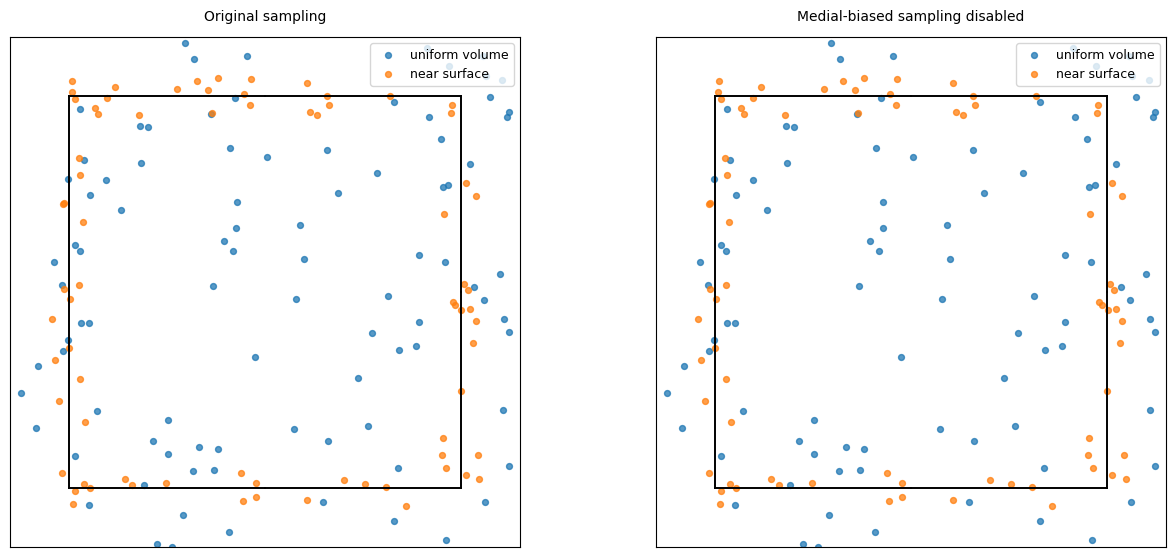

In [8]:
# Compare the original queries with the final medial-biased training set.
fig, axes = plt.subplots(1, 2, figsize=(12.8, 6.0))
draw_sampling_slice(
    axes[0], base_query_points, base_query_kinds, 'Original sampling')
sampling_title = (
    'With GT-ridge band sampling' if USE_MEDIAL_BIASED_SAMPLING
    else 'Medial-biased sampling disabled')
draw_sampling_slice(axes[1], query_points, query_kinds, sampling_title)
fig.subplots_adjust(wspace=0.16, left=0.04, right=0.98, top=0.90, bottom=0.05)
plt.show()

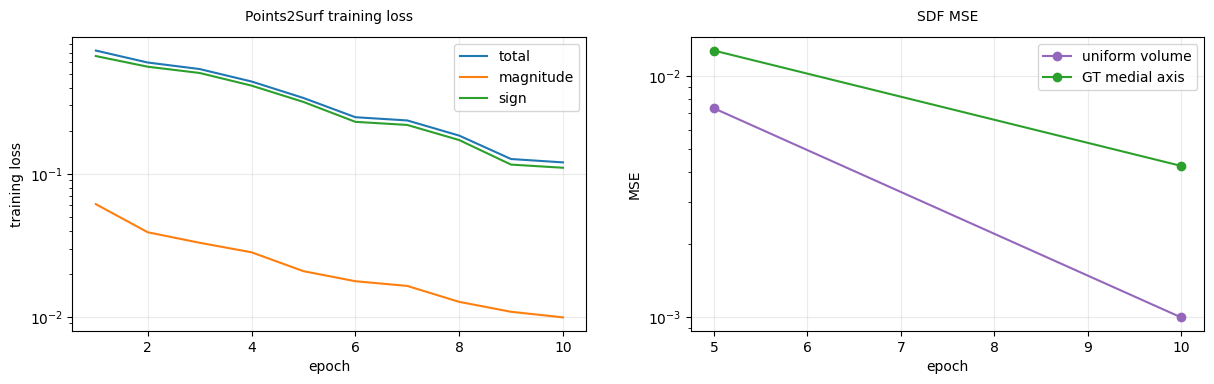

In [9]:
import matplotlib.pyplot as plt

fig, (loss_ax, mse_ax) = plt.subplots(1, 2, figsize=(12.5, 4.2))
epochs = np.arange(1, len(history['total']) + 1)
loss_ax.plot(epochs, history['total'], label='total')
loss_ax.plot(epochs, history['magnitude'], label='magnitude')
loss_ax.plot(epochs, history['sign'], label='sign')
loss_ax.set(xlabel='epoch', ylabel='training loss')
loss_ax.set_yscale('log')
loss_ax.set_title('Points2Surf training loss', fontsize=10, pad=12)
loss_ax.grid(alpha=0.25)
loss_ax.legend()

eval_mse = np.asarray(history['eval_mse'])
evaluated = np.isfinite(eval_mse)
mse_ax.plot(epochs[evaluated], eval_mse[evaluated], marker='o',
            color='tab:purple', label='uniform volume')
eval_medial_mse = np.asarray(history['eval_medial_mse'])
mse_ax.plot(epochs[evaluated], eval_medial_mse[evaluated], marker='o',
            color='tab:green', label='GT medial axis')
mse_ax.set(xlabel='epoch', ylabel='MSE')
mse_ax.set_yscale('log')
mse_ax.set_title('SDF MSE', fontsize=10, pad=12)
mse_ax.grid(alpha=0.25)
mse_ax.legend()
fig.tight_layout(pad=2.0, w_pad=3.0)
plt.show()

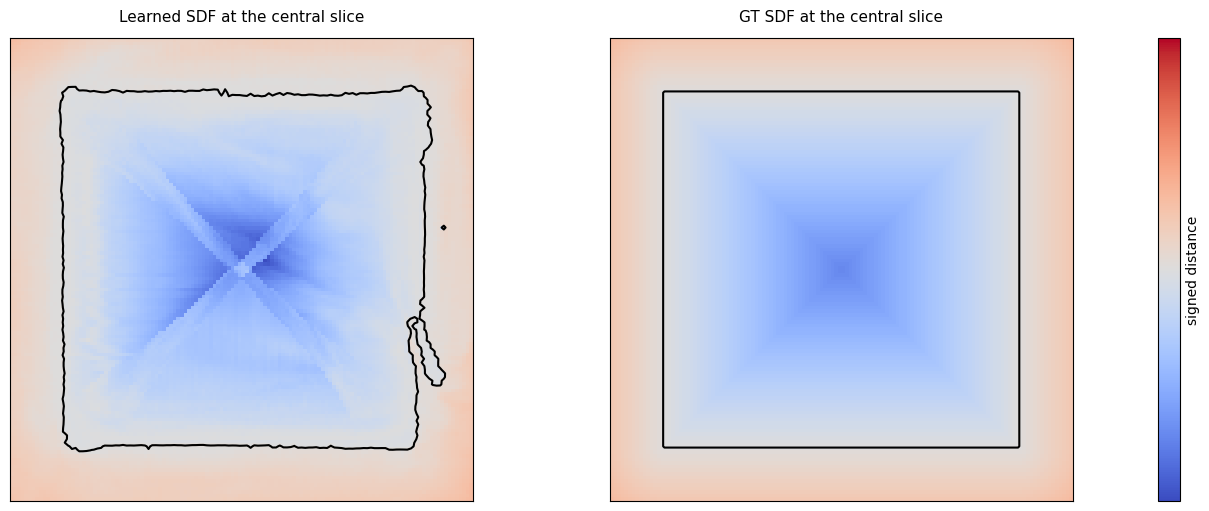

In [10]:
# Learned SDF on the centered XY slice (z = 0).
SLICE_RESOLUTION = 128

axis_values = np.linspace(-0.65, 0.65, SLICE_RESOLUTION, dtype=np.float32)
xx, yy = np.meshgrid(axis_values, axis_values)
slice_queries = np.column_stack((xx.ravel(), yy.ravel(), np.zeros(xx.size, dtype=np.float32)))

slice_sdf = predict_sdf_queries(slice_queries).reshape(
    SLICE_RESOLUTION, SLICE_RESOLUTION)
gt_slice_sdf = -sdf.get_signed_distance(mesh, slice_queries).reshape(
    SLICE_RESOLUTION, SLICE_RESOLUTION)
color_limit = max(float(np.abs(slice_sdf).max()), float(np.abs(gt_slice_sdf).max()), 1e-6)

fig = plt.figure(figsize=(12.5, 5), constrained_layout=True)
grid = fig.add_gridspec(1, 3, width_ratios=(1, 1, 0.04), wspace=0.08)
axes = (fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1]))
colorbar_ax = fig.add_subplot(grid[0, 2])
for ax, field, title in zip(
        axes, (slice_sdf, gt_slice_sdf), ('Learned SDF', 'GT SDF')):
    image = ax.imshow(
        field, origin='lower', extent=[axis_values[0], axis_values[-1]] * 2,
        cmap='coolwarm', vmin=-color_limit, vmax=color_limit)
    if field.min() < 0 < field.max():
        ax.contour(xx, yy, field, levels=[0], colors='black', linewidths=1.5)
    ax.set(aspect='equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'{title} at the central slice', fontsize=11, pad=12)

colorbar = fig.colorbar(image, cax=colorbar_ax, label='signed distance')
colorbar.set_ticks([])
plt.show()